# Perbandingan Algoritma Random Forest dan XGBoost untuk Klasifikasi Serangan Jaringan pada Dataset Network Intrusion Detection

bertujuan membandingkan performa Random Forest dan XGBoost untuk klasifikasi koneksi jaringan `normal` dan `anomaly`.

Alur metodologi Data Science:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Model Evaluation
6. Kesimpulan

## 1. Business Understanding

Masalah yang diangkat adalah deteksi intrusi jaringan. Dalam lalu lintas jaringan, koneksi dapat berupa koneksi normal atau koneksi berbahaya/anomaly. Karena volume data jaringan besar, dibutuhkan model machine learning untuk membantu klasifikasi koneksi secara otomatis.

Tugas analitik pada project ini adalah **klasifikasi biner**, yaitu memprediksi apakah sebuah koneksi termasuk `normal` atau `anomaly`.

Model yang dibandingkan:

- Random Forest
- XGBoost

Metrik evaluasi yang digunakan:

- Accuracy
- Precision
- Recall/Sensitivity
- Specificity
- F1-score
- ROC-AUC
- Confusion Matrix

## 2. Data Understanding

Dataset berasal dari Kaggle Network Intrusion Detection. File yang digunakan untuk training dan evaluasi adalah `Train_data.csv` karena file tersebut memiliki label target `class`. File `Test_data.csv` tidak digunakan untuk evaluasi karena tidak memiliki label target.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
DATA_PATH = Path("../data/raw/Train_data.csv")
df = pd.read_csv(DATA_PATH)

print("Ukuran dataset:", df.shape)
display(df.head())

Ukuran dataset: (25192, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [3]:
print("Informasi dataset:")
df.info()

print("\nJumlah missing value:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nJumlah duplikasi:", df.duplicated().sum())

print("\nDistribusi target:")
display(df["class"].value_counts())

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 1

duration          0
protocol_type     0
service           0
flag              0
src_bytes         0
dst_bytes         0
land              0
wrong_fragment    0
urgent            0
hot               0
dtype: int64


Jumlah duplikasi: 0

Distribusi target:


class
normal     13449
anomaly    11743
Name: count, dtype: int64

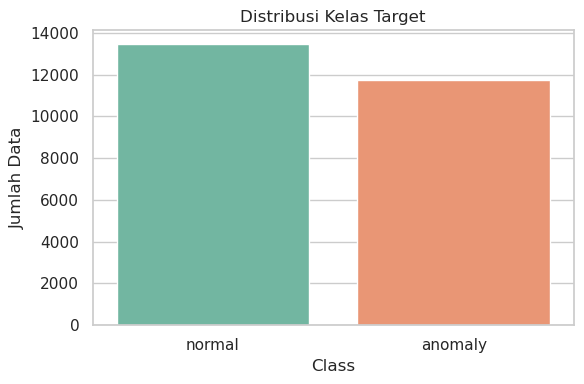

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="class", hue="class", palette="Set2", legend=False)
plt.title("Distribusi Kelas Target")
plt.xlabel("Class")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()

### Exploratory Data Analysis (EDA)

EDA dilakukan pada tahap Data Understanding untuk menelaah karakteristik data sebelum pemodelan. Pada bagian ini dilakukan statistik deskriptif, visualisasi fitur kategorikal, dan analisis korelasi fitur numerik terhadap target.

In [5]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
duration,25192.0,305.054104,2.686556e+03,0.0,0.00,0.00,0.00,42862.0
src_bytes,25192.0,24330.628215,2.410805e+06,0.0,0.00,44.00,279.00,381709090.0
dst_bytes,25192.0,3491.847174,8.883072e+04,0.0,0.00,0.00,530.25,5151385.0
land,25192.0,0.000079,8.909946e-03,0.0,0.00,0.00,0.00,1.0
wrong_fragment,25192.0,0.023738,2.602208e-01,0.0,0.00,0.00,0.00,3.0
urgent,25192.0,0.000040,6.300408e-03,0.0,0.00,0.00,0.00,1.0
hot,25192.0,0.198039,2.154202e+00,0.0,0.00,0.00,0.00,77.0
num_failed_logins,25192.0,0.001191,4.541818e-02,0.0,0.00,0.00,0.00,4.0
logged_in,25192.0,0.394768,4.888105e-01,0.0,0.00,0.00,1.00,1.0
num_compromised,25192.0,0.227850,1.041735e+01,0.0,0.00,0.00,0.00,884.0


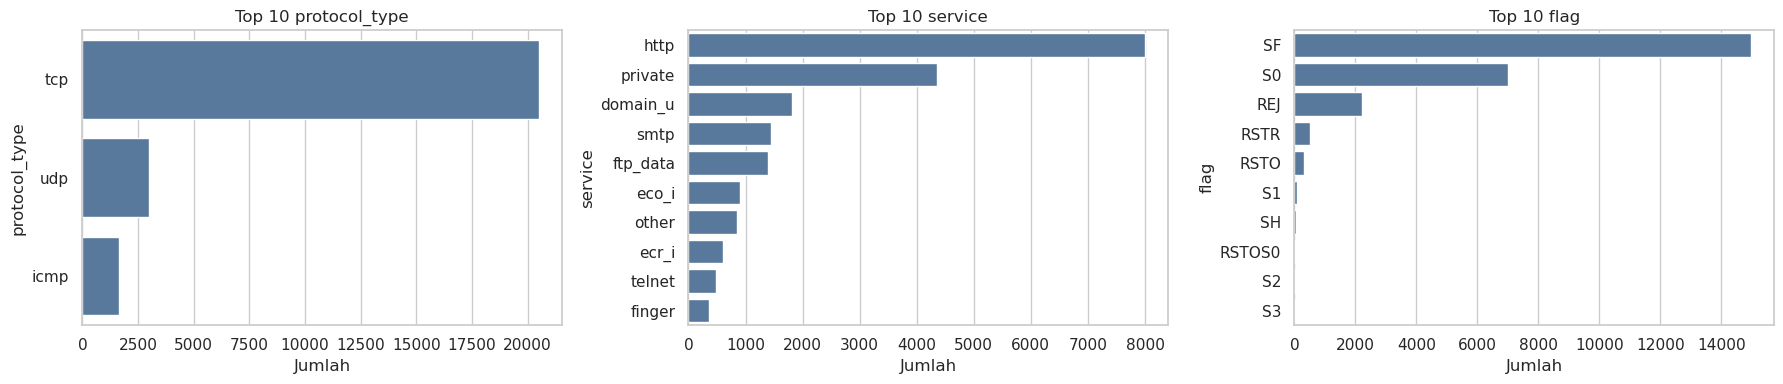

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, ["protocol_type", "service", "flag"]):
    top_values = df[col].value_counts().head(10)
    sns.barplot(x=top_values.values, y=top_values.index, ax=ax, color="#4C78A8")
    ax.set_title(f"Top 10 {col}")
    ax.set_xlabel("Jumlah")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

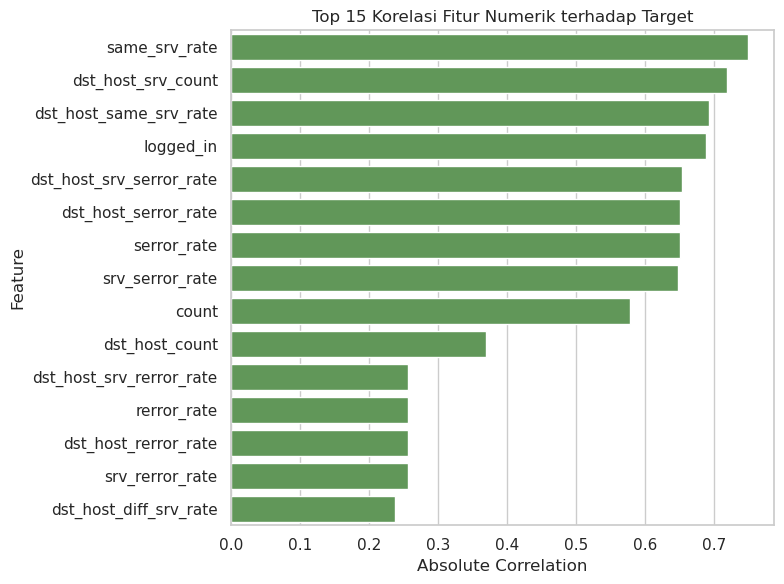

,absolute_correlation
same_srv_rate,0.749237
dst_host_srv_count,0.719292
dst_host_same_srv_rate,0.692212
logged_in,0.688084
dst_host_srv_serror_rate,0.653759
dst_host_serror_rate,0.651050
serror_rate,0.649952
srv_serror_rate,0.647817
count,0.578790
dst_host_count,0.368828


In [7]:
df_eda = df.copy()
df_eda["target"] = (df_eda["class"] != "normal").astype(int)

corr_with_target = (
    df_eda
    .select_dtypes(include=["int64", "float64"])
    .corr()["target"]
    .drop("target")
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 6))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, color="#59A14F")
plt.title("Top 15 Korelasi Fitur Numerik terhadap Target")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(corr_with_target.to_frame("absolute_correlation"))

## 3. Data Preparation

Langkah persiapan data:

1. Mengubah target menjadi binary: `normal = 0`, `anomaly = 1`.
2. Memisahkan fitur (`X`) dan target (`y`).
3. Mengidentifikasi fitur kategorikal dan numerik.
4. Membagi data menjadi 70% training dan 30% testing dengan stratifikasi.
5. Mengubah fitur kategorikal menjadi numerik menggunakan One-Hot Encoding.

In [8]:
df_model = df.copy()
df_model["target"] = (df_model["class"] != "normal").astype(int)

X = df_model.drop(columns=["class", "target"])
y = df_model["target"]

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Fitur kategorikal:", categorical_features)
print("Jumlah fitur numerik:", len(numeric_features))
display(y.value_counts().rename(index={0: "normal", 1: "anomaly"}))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

print("Data training:", X_train.shape)
print("Data testing:", X_test.shape)

Fitur kategorikal: ['protocol_type', 'service', 'flag']
Jumlah fitur numerik: 38


target
normal     13449
anomaly    11743
Name: count, dtype: int64

Data training: (17634, 41)
Data testing: (7558, 41)


## 4. Modeling

Dua model dibuat dengan preprocessing yang sama agar perbandingan lebih adil. Random Forest menggunakan `class_weight="balanced"`, sedangkan XGBoost menggunakan `scale_pos_weight` berdasarkan proporsi kelas pada data training.

In [9]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                class_weight="balanced",
            ),
        ),
    ]
)

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

xgb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            XGBClassifier(
                n_estimators=100,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                scale_pos_weight=scale_pos_weight,
            ),
        ),
    ]
)

rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

print("Training selesai.")

Training selesai.


## 5. Model Evaluation

Evaluasi dilakukan pada data testing. Confusion matrix dibaca dengan format:

```text
[[TN FP]
 [FN TP]]
```

Pada kasus intrusion detection, false negative penting diperhatikan karena berarti data anomaly diprediksi sebagai normal.

In [10]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    result = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall_sensitivity": recall_score(y_test, y_pred),
        "specificity": specificity,
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "false_positive": fp,
        "false_negative": fn,
    }

    print(f"=== {name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["normal", "anomaly"]))
    print()
    return result

results = [
    evaluate_model("Random Forest", rf_pipeline, X_test, y_test),
    evaluate_model("XGBoost", xgb_pipeline, X_test, y_test),
]

results_df = pd.DataFrame(results)
display(results_df)

=== Random Forest ===
Confusion Matrix:
[[4031    4]
 [  19 3504]]

Classification Report:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      4035
     anomaly       1.00      0.99      1.00      3523

    accuracy                           1.00      7558
   macro avg       1.00      1.00      1.00      7558
weighted avg       1.00      1.00      1.00      7558


=== XGBoost ===
Confusion Matrix:
[[4028    7]
 [  17 3506]]

Classification Report:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      4035
     anomaly       1.00      1.00      1.00      3523

    accuracy                           1.00      7558
   macro avg       1.00      1.00      1.00      7558
weighted avg       1.00      1.00      1.00      7558




,model,accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,false_positive,false_negative
0,Random Forest,0.996957,0.998860,0.994607,0.999009,0.996729,0.999939,4,19
1,XGBoost,0.996825,0.998007,0.995175,0.998265,0.996589,0.999949,7,17


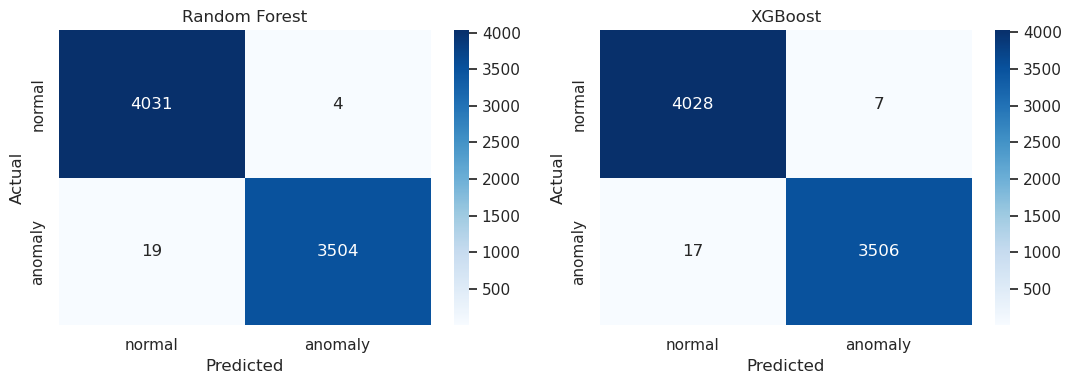

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, name, model in zip(
    axes,
    ["Random Forest", "XGBoost"],
    [rf_pipeline, xgb_pipeline],
):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["normal", "anomaly"],
        yticklabels=["normal", "anomaly"],
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

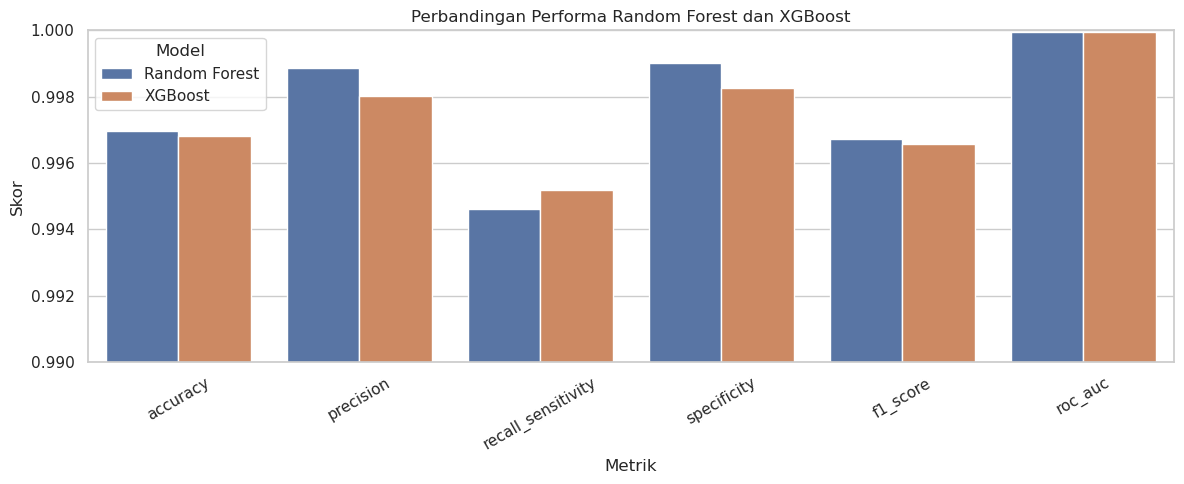

In [12]:
metrics_to_plot = [
    "accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
]

results_melted = results_df.melt(
    id_vars="model",
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 5))
sns.barplot(data=results_melted, x="metric", y="score", hue="model")
plt.ylim(0.99, 1.0)
plt.title("Perbandingan Performa Random Forest dan XGBoost")
plt.xlabel("Metrik")
plt.ylabel("Skor")
plt.xticks(rotation=30)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

## 6. Feature Importance

Feature importance digunakan untuk melihat fitur yang paling berkontribusi pada model Random Forest. Interpretasi ini membantu menjelaskan fitur mana yang paling banyak digunakan model dalam membedakan koneksi normal dan anomaly.

,feature,importance
82,dst_bytes,0.110869
81,src_bytes,0.103792
106,diff_srv_rate,0.067574
105,same_srv_rate,0.054855
99,count,0.048667
78,flag_SF,0.046055
109,dst_host_srv_count,0.043602
88,logged_in,0.042330
102,srv_serror_rate,0.042261
111,dst_host_diff_srv_rate,0.036241


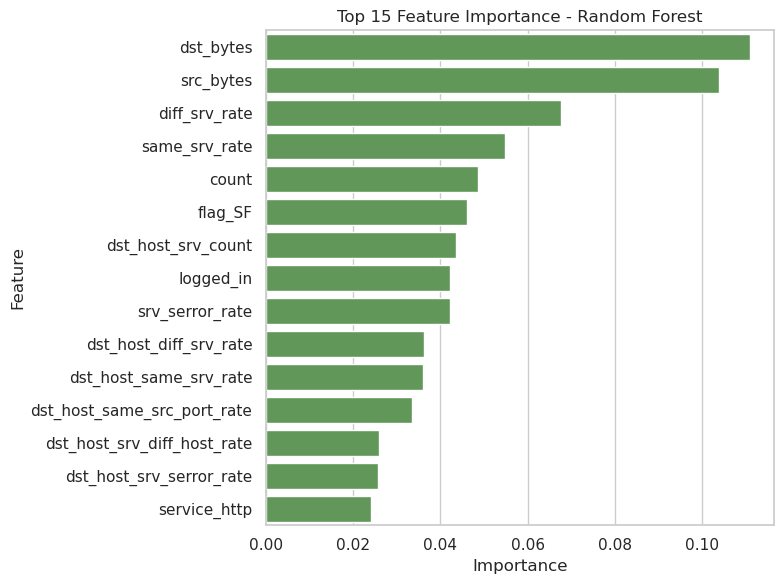

In [13]:
preprocessor = rf_pipeline.named_steps["preprocess"]
rf_model = rf_pipeline.named_steps["model"]

cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
feature_names = np.concatenate([cat_feature_names, numeric_features])

rf_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(rf_importances.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(data=rf_importances.head(15), x="importance", y="feature", color="#59A14F")
plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 7. Kesimpulan

Berdasarkan hasil evaluasi, Random Forest dan XGBoost sama-sama memiliki performa sangat tinggi dalam klasifikasi koneksi jaringan normal dan anomaly. Random Forest unggul sedikit pada accuracy, precision, specificity, dan F1-score. XGBoost unggul sedikit pada recall/sensitivity dan ROC-AUC.

Dari confusion matrix, Random Forest memiliki false positive lebih rendah, sedangkan XGBoost memiliki false negative lebih rendah. Dalam konteks network intrusion detection, false negative penting karena berarti koneksi anomaly tidak terdeteksi. Namun, karena selisih performa kedua model sangat kecil, keduanya dapat dianggap memiliki performa yang hampir setara.

Secara keseluruhan, Random Forest dapat dipilih sebagai model terbaik berdasarkan keseimbangan metrik evaluasi. XGBoost dapat dipertimbangkan apabila prioritas utama adalah meminimalkan anomaly yang lolos tidak terdeteksi.